In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
data=pd.read_csv("titanic/train.csv")

In [40]:
data.shape

(891, 12)

In [41]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [42]:
data.drop('Cabin', axis=1, inplace=True)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [43]:
print(data['Age'].mean())
print(data['Fare'].mean())
data[ (data['Age']>=25) &  (data['Age']<=30)]
data[ data['Fare']<300]

29.69911764705882
32.204207968574636


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


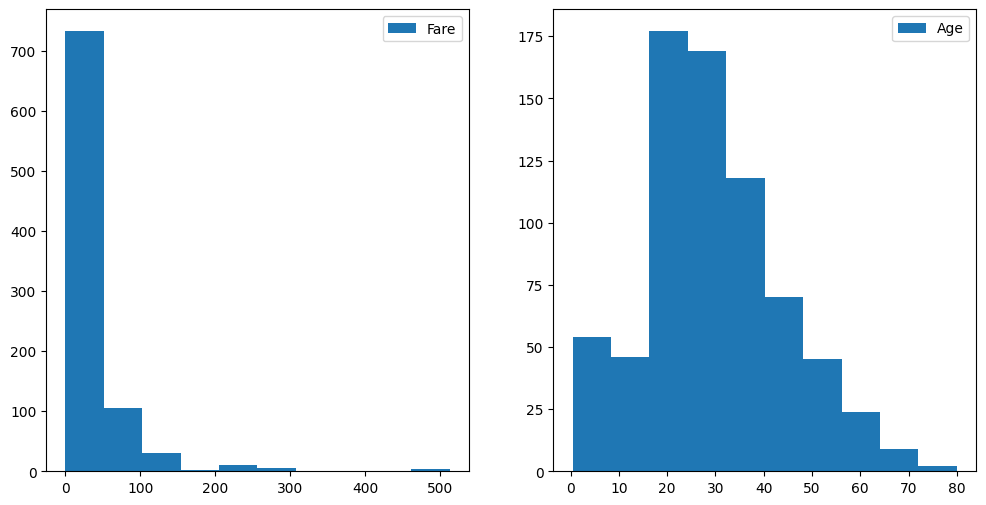

In [44]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(data['Fare'], label='Fare')
plt.legend()
plt.subplot(1,2,2)
plt.hist(data['Age'], label='Age', bins=10)
plt.legend()

<Axes: xlabel='Sex', ylabel='Count'>

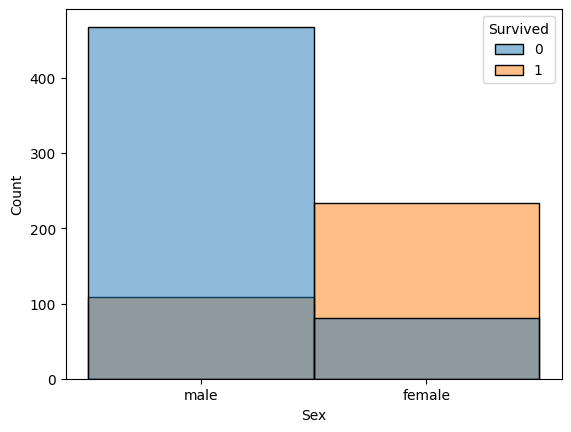

In [45]:
sns.histplot(data=data, x='Sex', hue='Survived')

<Axes: xlabel='Sex', ylabel='Survived'>

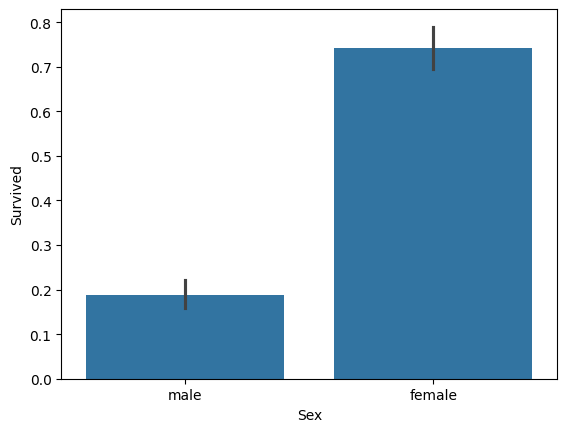

In [46]:
sns.barplot(data=data, x='Sex', y='Survived')

In [47]:
data[(data['Survived']==0) & (data['Sex'] == 'female')].shape[0]+data[(data['Survived']==1) & (data['Sex'] == 'female')].shape[0]

314

In [48]:
female=data[data['Sex']=='female']
male=data[data['Sex']!='female']
survived=data[data['Survived']==1]

In [49]:
survived.shape[0]/data.shape[0]

0.3838383838383838

In [50]:
data[(data['Survived']==1) & (data['Sex'] == 'female')].shape[0]/data.shape[0]

0.2615039281705948

In [51]:
data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='Survived'>

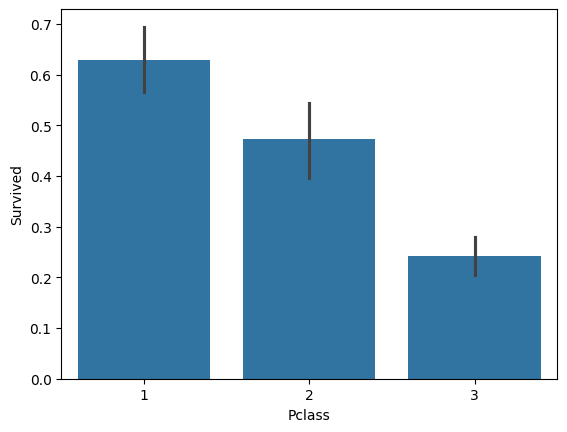

In [52]:
sns.barplot(data=data, x='Pclass', y='Survived')

In [53]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [54]:
df=data.replace(['female','male'],[0,1])
correlations=df.select_dtypes(include='number').corr()['Survived'].drop(['PassengerId','Survived'])
sorted_correlations=correlations.sort_values(ascending=False)
sorted_correlations

/tmp/ipykernel_18245/4121549394.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=data.replace(['female','male'],[0,1])


Fare      0.257307
Parch     0.081629
SibSp    -0.035322
Age      -0.077221
Pclass   -0.338481
Sex      -0.543351
Name: Survived, dtype: float64

<Axes: >

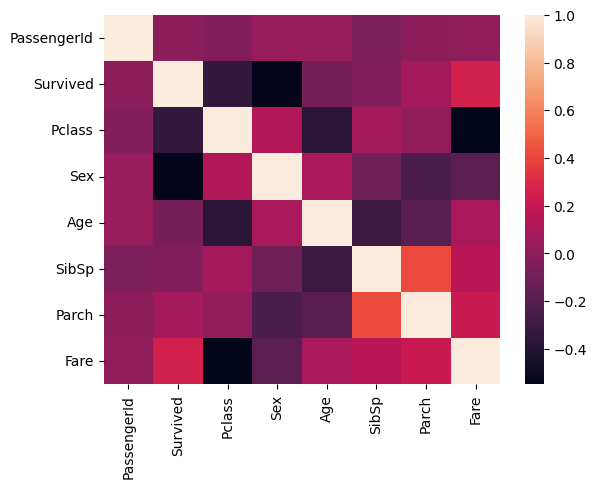

In [55]:
sns.heatmap(df.select_dtypes(include='number').corr())

In [56]:
data.select_dtypes(exclude='number')

,Name,Sex,Ticket,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,S
4,"Allen, Mr. William Henry",male,373450,S
...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,S
887,"Graham, Miss. Margaret Edith",female,112053,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,S
889,"Behr, Mr. Karl Howell",male,111369,C


In [57]:
from sklearn.impute import SimpleImputer, KNNImputer

cab_imputer=KNNImputer(n_neighbors=1)
age_imputer=SimpleImputer(strategy='median')
emb_imputer=SimpleImputer(strategy='most_frequent')
df=data.copy()

In [58]:
data['Embarked'].isna().sum()

np.int64(2)

In [59]:
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [60]:
df['Age']=age_imputer.fit_transform(df[['Age']])
df['Embarked']=emb_imputer.fit_transform(df[['Embarked']]).ravel()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [61]:
code =data[['Sex', 'Embarked']]

In [62]:
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [63]:
# Emputer (gerer les Nan) , puis encoder des variables categorielles
# Gerer les Nan puis standardiser (voir normaliser ) les variables numeriques (sur les colonnes et age et fare)

# On va :
#  SimpleImpute by the most_frequent(pour commencer) nos var categorielles puis encoder OneHot

data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [184]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [ ]:
# Traitement des variables categorielles ( Sex et Embarked)
#   On va Imputer Embarked et encoder les deux avec OneHotEncoder

In [67]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [68]:
categorical=['Sex','Embarked']
numerical=['Age','Fare']

In [69]:
categorical_pipeline=make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder())

num_forest_pipeline=make_pipeline(SimpleImputer(strategy='median'))
num_other_pipeline=make_pipeline(SimpleImputer(strategy='median'),StandardScaler())

In [70]:
processor=make_column_transformer((num_other_pipeline,numerical),(categorical_pipeline,categorical))
forest_processor=make_column_transformer((num_forest_pipeline,numerical),(categorical_pipeline,categorical))

In [71]:
model=make_pipeline(processor,KNeighborsClassifier(7))
forest=make_pipeline(forest_processor, RandomForestClassifier)

In [72]:
x=data.drop('Survived',axis=1)
y=data['Survived']

In [199]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve,GridSearchCV
x_train,x_test, y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=0)

In [74]:
model.fit(x_train, y_train)

,steps,"[('columntransformer', ...), ('kneighborsclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
model.score(x_test,y_test)
ypred=model.predict(x_test)

In [76]:
print(confusion_matrix(y_test,ypred))

[[96 14]
 [25 44]]


In [77]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



In [79]:
liste=[]
for k in range(1,25):
    model=make_pipeline(processor,KNeighborsClassifier(n_neighbors=k))
    score=cross_val_score(model, x_test, y_test, cv=4, scoring='f1')
    liste.append(score.mean())

Text(0.5, 1.0, 'Choix du meilleur k pour KNN')

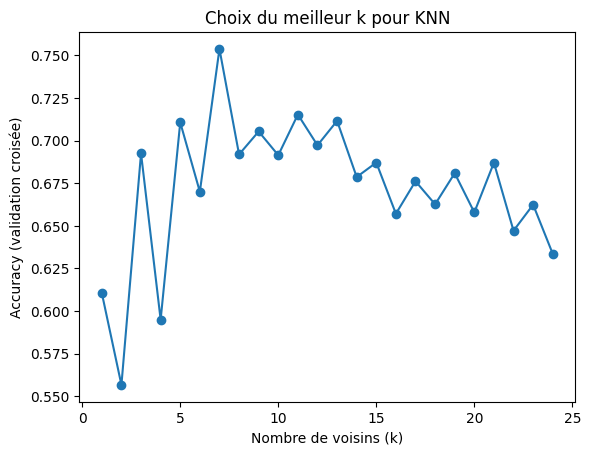

In [80]:
plt.plot(range(1,25), liste, marker='o')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Accuracy (validation croisée)')
plt.title('Choix du meilleur k pour KNN')

In [82]:
models={
    'knn':KNeighborsClassifier(n_neighbors=7),
     'Logreg':LogisticRegression(max_iter=100),
      'GDB':GradientBoostingClassifier()
}

In [160]:
Best={}
def fun_best(dictionnaire):
  for name, mod in dictionnaire.items():
     model=make_pipeline(processor,mod)
     score = cross_val_score(model, x_train,y_train, cv=4, scoring='f1').mean()
     print(score)
     Best[name]=score
     print(f"{name} → F1 = {score:.3f}")
  return Best

In [161]:
Best = fun_best(models)
best_model_name = max(Best, key=Best.get)
best_model = models[best_model_name] # models est notre dictionnaire de base (avec les noms des modeles)

0.6804496288441146
knn → F1 = 0.680
0.7056934284223529
Logreg → F1 = 0.706
0.7182572570019976
GDB → F1 = 0.718


In [162]:
ml=make_pipeline(processor,best_model)

In [163]:
ml.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [166]:
print("train score", ml.score(x_train,y_train))
print("test score", ml.score(x_test,y_test))

train score 0.8876404494382022
test score 0.8212290502793296


In [178]:
N, train_scores,val_scores=learning_curve(ml, x_train,y_train, cv=4, scoring='f1',n_jobs=-1,train_sizes=np.linspace(0.1, 1.0, 6),random_state=42)

In [ ]:
#plt.fill_between(x, y1, y2, color='couleur', alpha=transparence)

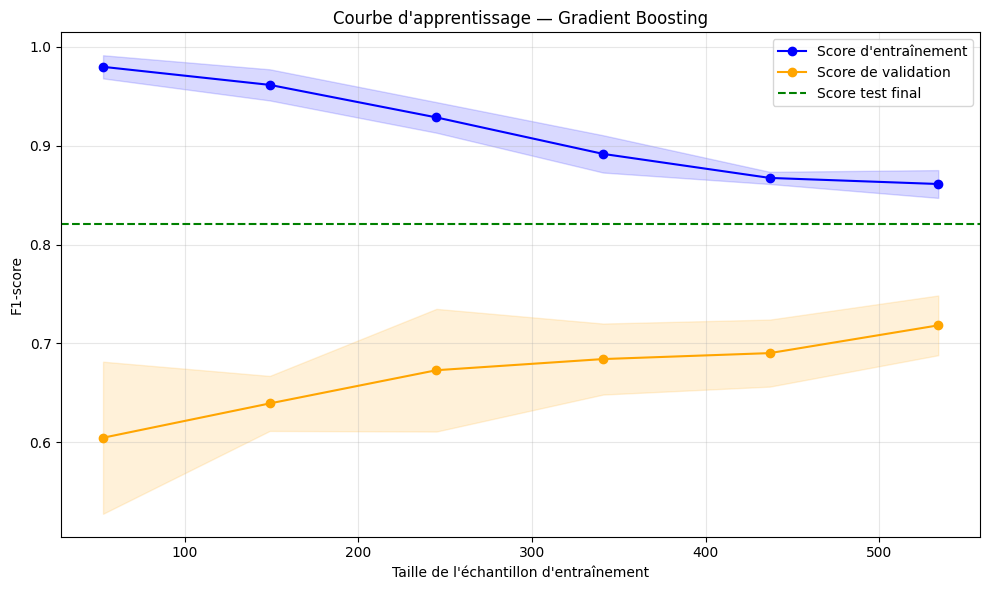

In [183]:
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Visualisation
plt.figure(figsize=(10,6))
plt.plot(N, train_mean, 'o-', color='blue', label='Score d\'entraînement')
plt.plot(N, val_mean, 'o-', color='orange', label='Score de validation')

# Bandes d’incertitude (± écart-type)
plt.fill_between(N, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='blue')
plt.fill_between(N, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='orange')

# Mise en forme 
plt.title('Courbe d\'apprentissage — Gradient Boosting')
plt.xlabel('Taille de l\'échantillon d\'entraînement')
plt.ylabel('F1-score')
plt.grid(alpha=0.3)
plt.axhline(y=ml.score(x_test, y_test), color='green', linestyle='--', label='Score test final')
plt.legend()
plt.tight_layout()


In [200]:
GradientBoostingClassifier()

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [215]:
param_grid={
    "gradientboostingclassifier__n_estimators":[100,200,300],
    "gradientboostingclassifier__learning_rate":[0.01,0.05,0.1],
    "gradientboostingclassifier__max_depth":[2,3,4],
    "gradientboostingclassifier__subsample":[0.8,1.0]
}

grid=GridSearchCV(ml,param_grid,scoring='f1',cv=5, n_jobs=-1)

In [214]:
ml.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'columntransformer', 'gradientboostingclassifier', 'columntransformer__force_int_remainder_cols', 'columntransformer__n_jobs', 'columntransformer__remainder', 'columntransformer__sparse_threshold', 'columntransformer__transformer_weights', 'columntransformer__transformers', 'columntransformer__verbose', 'columntransformer__verbose_feature_names_out', 'columntransformer__pipeline-1', 'columntransformer__pipeline-2', 'columntransformer__pipeline-1__memory', 'columntransformer__pipeline-1__steps', 'columntransformer__pipeline-1__transform_input', 'columntransformer__pipeline-1__verbose', 'columntransformer__pipeline-1__simpleimputer', 'columntransformer__pipeline-1__standardscaler', 'columntransformer__pipeline-1__simpleimputer__add_indicator', 'columntransformer__pipeline-1__simpleimputer__copy', 'columntransformer__pipeline-1__simpleimputer__fill_value', 'columntransformer__pipeline-1__simpleimputer__keep_empty_features', 'colu

In [216]:
grid.fit(x_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'gradientboostingclassifier__learning_rate': [0.01, 0.05, ...], 'gradientboostingclassifier__max_depth': [2, 3, ...], 'gradientboostingclassifier__n_estimators': [100, 200, ...], 'gradientboostingclassifier__subsample': [0.8, 1.0]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"


In [237]:
grid.best_score_

np.float64(0.7383007266026134)

In [231]:
y_pred=ml.predict(x_test)
g_pred=grid.predict(x_test)

In [232]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [233]:
print(classification_report(y_test, g_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       110
           1       0.79      0.77      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



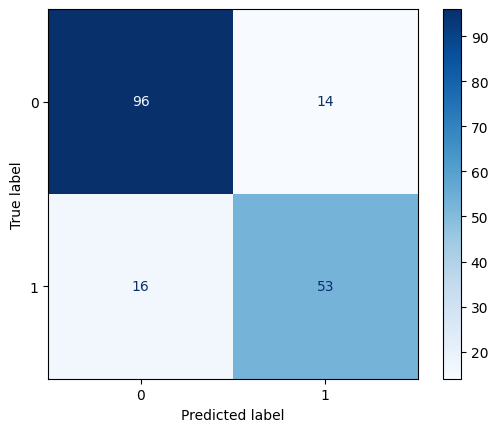

In [235]:
ConfusionMatrixDisplay(confusion_matrix(y_test,g_pred)).plot(cmap='Blues')

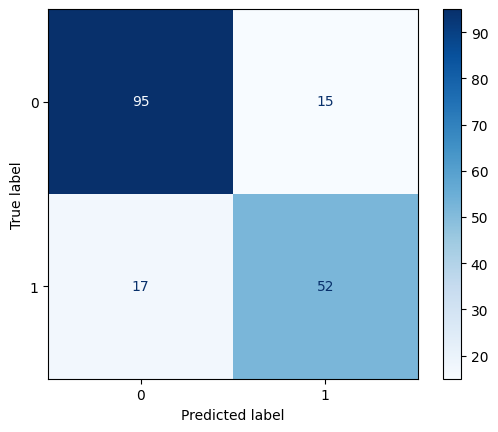

In [236]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot(cmap='Blues')

In [1]:
121/151

0.8013245033112583